# 01a · Crossdocked Dataset Viewer

Browse the CrossDocked dataset used by VoxBind: dataset summary, atom-type distribution, and a 3D viewer for a chosen pocket–ligand pair.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from voxbind.constants import (
    ELEMENTS_HASH_CROSSDOCKED, N_POCKET_ELEMENTS, N_LIGAND_ELEMENTS,
)

DATA_DIR    = Path("..") / "voxbind" / "dataset" / "data"
IDX_TO_ELEM = {v: k for k, v in ELEMENTS_HASH_CROSSDOCKED.items()}
POCKET_ELEMS = [IDX_TO_ELEM[i] for i in range(N_POCKET_ELEMENTS)]
LIGAND_ELEMS = [IDX_TO_ELEM[i] for i in range(N_LIGAND_ELEMENTS)]
ELEM_COLOR = {"C": "#808080", "N": "#3498db", "O": "#e74c3c",
              "S": "#f1c40f", "F": "#2ecc71", "Cl": "#27ae60", "P": "#e67e22"}


## 1. Dataset summary

Train / Test / Total : 99,981 / 100 / 100,081
Pocket atoms (4 types) : {'C': 25501033, 'O': 7287508, 'N': 6580418, 'S': 283466}
Ligand atoms (7 types) : {'C': 1586262, 'O': 400726, 'N': 276504, 'S': 26552, 'F': 30875, 'Cl': 15221, 'P': 26331}


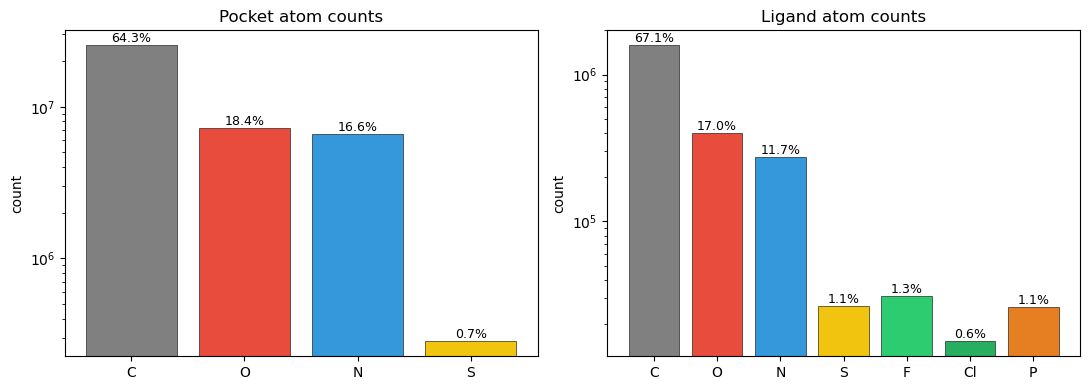

In [2]:
data_train = torch.load(DATA_DIR / "data_train.pt", weights_only=False)
data_test  = torch.load(DATA_DIR / "data_test.pt",  weights_only=False)
data_all   = data_train + data_test

poc_counts = np.zeros(N_POCKET_ELEMENTS, dtype=np.int64)
lig_counts = np.zeros(N_LIGAND_ELEMENTS, dtype=np.int64)
for poc, lig in data_all:
    pc = poc["atoms_channel"].numpy()
    lc = lig["atoms_channel"].numpy()
    for i in range(N_POCKET_ELEMENTS): poc_counts[i] += (pc == i).sum()
    for i in range(N_LIGAND_ELEMENTS): lig_counts[i] += (lc == i).sum()

print(f"Train / Test / Total : {len(data_train):,} / {len(data_test):,} / {len(data_all):,}")
print(f"Pocket atoms ({N_POCKET_ELEMENTS} types) : {dict(zip(POCKET_ELEMS, poc_counts))}")
print(f"Ligand atoms ({N_LIGAND_ELEMENTS} types) : {dict(zip(LIGAND_ELEMS, lig_counts))}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, names, counts, title in (
    (axes[0], POCKET_ELEMS, poc_counts, "Pocket"),
    (axes[1], LIGAND_ELEMS, lig_counts, "Ligand"),
):
    pct = counts / counts.sum() * 100
    bars = ax.bar(names, counts, color=[ELEM_COLOR[e] for e in names],
                  edgecolor="black", linewidth=0.4)
    for bar, p in zip(bars, pct):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f"{p:.1f}%", ha="center", va="bottom", fontsize=9)
    ax.set_yscale("log")
    ax.set_title(f"{title} atom counts")
    ax.set_ylabel("count")
fig.tight_layout()
plt.show()


## 2. Select a sample by PDB ID

Sets `pocket_raw`, `ligand_raw`, and `data_split` to the matching sample.


In [3]:
TARGET_PDB_ID = "14gs"   # 4-letter PDB code
SPLIT         = "test"  # search this split first

def extract_pdb_id(pocket_id: str) -> str:
    return pocket_id.split("/")[1].split("_")[0].upper()

def find_sample(pdb: str, data):
    for i, (poc, lig) in enumerate(data):
        if extract_pdb_id(poc["id"]) == pdb.upper():
            return i, poc, lig
    return None

data_split = data_test if SPLIT == "test" else data_train
hit = find_sample(TARGET_PDB_ID, data_split) \
      or find_sample(TARGET_PDB_ID, data_train if SPLIT == "test" else data_test)
if hit is None:
    raise ValueError(f"{TARGET_PDB_ID!r} not found in dataset")

SAMPLE_IDX, pocket_raw, ligand_raw = hit

print(f"PDB {TARGET_PDB_ID.upper()}  →  SAMPLE_IDX={SAMPLE_IDX}")
print(f"Pocket {pocket_raw['id']}")
print(f"  atoms = {pocket_raw['coords'].shape[0]}")
print(f"Ligand {ligand_raw['id']}")
print(f"  atoms = {ligand_raw['coords'].shape[0]},  max_len = {ligand_raw['max_len']} \u00c5")


PDB 14GS  →  SAMPLE_IDX=3
Pocket GSTP1_HUMAN_2_210_0/14gs_A_rec_20gs_cbd_lig_tt_min_0_pocket10.pdb
  atoms = 255
Ligand GSTP1_HUMAN_2_210_0/14gs_A_rec_20gs_cbd_lig_tt_min_0.sdf
  atoms = 22,  max_len = 7.86 Å


## 3. 3D viewer — pocket + ligand

Pocket atoms drawn in grey; ligand atoms coloured by element.

In [4]:
ELEM_COLORS = {
    "C": "gray", "O": "red", "N": "blue", "S": "gold",
    "F": "green", "Cl": "lime", "P": "orange", "H": "white",
}

fig = go.Figure()

# --- Pocket atoms (all shown in light grey) ---
poc_coords = pocket_raw["coords"].numpy()
fig.add_trace(go.Scatter3d(
    x=poc_coords[:, 0], y=poc_coords[:, 1], z=poc_coords[:, 2],
    mode="markers",
    marker=dict(size=3, color="lightgrey", opacity=0.85),
    name="Pocket",
))

# --- Ligand atoms (coloured by element) ---
lig_coords = ligand_raw["coords"].numpy()
lig_channels = ligand_raw["atoms_channel"].numpy()

for ch_idx in np.unique(lig_channels):
    elem = IDX_TO_ELEM.get(int(ch_idx), f"ch{int(ch_idx)}")
    mask = lig_channels == ch_idx
    fig.add_trace(go.Scatter3d(
        x=lig_coords[mask, 0], y=lig_coords[mask, 1], z=lig_coords[mask, 2],
        mode="markers",
        marker=dict(size=5, color=ELEM_COLORS.get(elem, "purple")),
        name=f"Ligand {elem}",
    ))

fig.update_layout(
    title=f"Pocket + Ligand  —  {pocket_raw['id']}",
    scene=dict(
        xaxis_title="x (Å)", yaxis_title="y (Å)", zaxis_title="z (Å)",
        aspectmode="data",
    ),
    width=800, height=650,
    legend=dict(itemsizing="constant"),
)
fig.show()

## 4. NGLView molecular surface (optional)

Pretty molecular rendering: pocket as translucent surface, ligand as ball-and-stick.

In [6]:
import nglview as nv

pdb_path = DATA_DIR / "crossdocked_pocket10" / pocket_raw["id"]
sdf_path = DATA_DIR / "crossdocked_pocket10" / ligand_raw["id"]

view = nv.NGLWidget(height="550px", width="650px")
view.add_component(str(pdb_path))
view.clear_representations(component=0)
view.add_representation("surface", component=0, opacity=0.4, color="electrostatic", surfaceType="av")
view.add_component(str(sdf_path))
view.clear_representations(component=1)
view.add_representation("ball+stick", component=1, colorScheme="element")
view.add_representation("surface", component=1, opacity=0.1, color="electrostatic", surfaceType="av")
view.center()
view


NGLWidget()